# PRG Toolbox Tutorial: 
### analysing large datasets with `run_PRG_in_directory`

This tutorial demonstrates how to leverage the `prg-toolbox` processing pipeline to automatically analyze multiple datasets stored within a single directory. While analyzing single files using `run_PRG` is useful for exploration, real-world workflows often involve parsing entire cohorts or experimental runs using a unified set of configurations.

The `run_PRG_in_directory` pipeline handles files inside a chosen folder and saves all results in a hashed folder containing a manifest with all the parameters used. This allows for reproducible analysis, regardless of the size of the analysis.

#### 📁 Example Directory Structure


```text
your_notebook_folder/
│
├── prg_tutorial.ipynb   <-- This Notebook
│
└── example_data_directory/          <-- Your input folder
    ├── subject_01.npy
    ├── subject_02.npy
    └── subject_03.npy
```
---
- In this example, we will analyse simulations from the large multi-area model from [Schmidt et al.(2018)](https://doi.org/10.1371/journal.pcbi.1006359). The example contains a folder with gdf files with neuronal spiking data stored as timestamps (one column with spike timings and another with neuron indices).

- We will take a single area (V4) and investigate its behavior at each cortical layer (23, 4, 5, 6). 

- In some cases, a dataset can have much more variables than it has time samples (which would hinder
correlation measurements in the analysis), we will subsample the neurons to a smaller 
number of neurons and repeat the analysis multiple times. the toolbox automatically 
averages the results over the different subsamples and returns the mean and standard 
deviation of the observables.

 ---

Let's access the data and analyse it:

In [1]:
import prg_toolbox as prg

# Download the spiking data from the example dataset and return the path to the folder
folder = prg.datasets.get_spike_data()  

print(folder)
# Initialize configuration parameters for the PRG analysis
prg_params = prg.config.AnalysisParams()  

# This example dataset has timestamps in .gdf files, so we use the 'tabular' format.
prg_params.loading.data_format = "tabular"

# Set parameters for the analysis
prg_params.rg_steps = 7
prg_params.observables = [
    prg.mean_variance, 
    prg.activity_distribution
]
# We will add some subsampling parameters to demonstrate the functionality
prg_params.subsampling.samplesize = 512
prg_params.subsampling.nsamples = 5
prg_params.subsampling.random_seed = 42 #for reproducibility

# This parses the directory, executes the analysis, plots, and saves results
result_dict = prg.pipelines.run_PRG_in_directory(
    file_directory=folder,
    user_params=prg_params,
    show_plots=False,
    save_plots=True,
    save_results=True
)

✔ Ready: /home/miranda-castro/Documents/projects/prg_toolbox/example_notebooks/example_data_directory/spikes-V4-6E.gdf
./example_data_directory
[1/4] Processing file: spikes-V4-5E.gdf
Saved → ./results/analysis_74aac32e9c971d62f380a94cc2c8fab662a33949/results/spikes-V4-5E.pkl
[2/4] Processing file: spikes-V4-23E.gdf
Saved → ./results/analysis_74aac32e9c971d62f380a94cc2c8fab662a33949/results/spikes-V4-23E.pkl
[3/4] Processing file: spikes-V4-6E.gdf
Saved → ./results/analysis_74aac32e9c971d62f380a94cc2c8fab662a33949/results/spikes-V4-6E.pkl
[4/4] Processing file: spikes-V4-4E.gdf
Saved → ./results/analysis_74aac32e9c971d62f380a94cc2c8fab662a33949/results/spikes-V4-4E.pkl


### We can now, for example, use the dictionaries saved to compare results from different files:

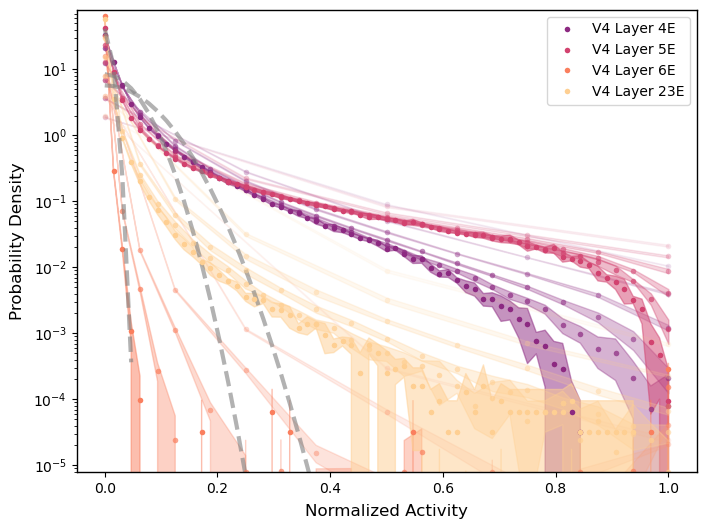

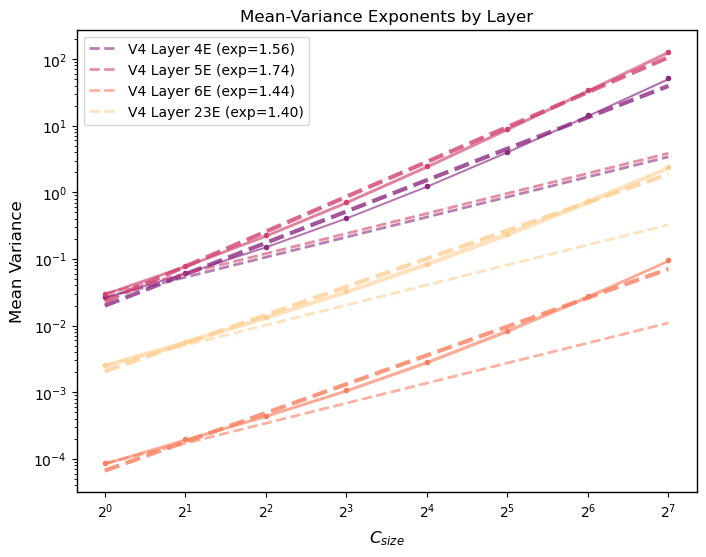

In [2]:
import pickle
import os
import matplotlib.pyplot as plt
import numpy as np
import prg_toolbox as prg

# Load results
results_path = './results/analysis_74aac32e9c971d62f380a94cc2c8fab662a33949/results'
pkl_files = [f for f in os.listdir(results_path)]  
alphas = np.zeros(len(pkl_files))

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
fig2, ax2 = plt.subplots(figsize=(8, 6))
colors = plt.cm.magma(np.linspace(0.4, 0.9, len(pkl_files)))  # Color map for different files
for i, pkl in enumerate(pkl_files):
    path = os.path.join(results_path, pkl)
    with open(path, "rb") as f:
        output_dict = pickle.load(f)

    # Save mean-variance exponents to insert in legend
    alphas[i] = output_dict["results"]["mean_variance"]['exponent'] 
    # Plotting activity distributions
    prg.plot.plot_activity_distribution(output_dict["results"]["activity_distribution"], plot_kwargs={'color': colors[i]}, fill_kwargs={'color': colors[i]}, style_config=prg_params, ax=ax)
    prg.plot.plot_mean_variance(output_dict["results"]["mean_variance"], plot_kwargs={'color':colors[i]}, fill_kwargs={'color':colors[i]}, style_config=prg_params, ax=ax2)
 

    # Handle legend labels externally for the mean-variance and activity distribution plots
    # Selecting the part of the string containing the layer index
    ax.get_lines()[-2].set_label(f'V4 Layer {pkl.split("-")[-1][:-4]}') 
    ax2.get_lines()[-1].set_label(f'V4 Layer {pkl.split("-")[-1][:-4]} (exp={alphas[i]:.2f})')
ax.legend()
ax2.legend()
title = ax2.set_title("Mean-Variance Exponents by Layer")
